In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, ConfusionMatrixDisplay, recall_score, accuracy_score
from sklearn.metrics import  f1_score, mean_absolute_error, auc, roc_curve, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [7]:
data = pd.read_csv("framingham.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'framingham.csv'

In [2]:
data.info()

NameError: name 'data' is not defined

In [ ]:
data.describe()

In [ ]:
data = data.drop(['education'], axis = 1)

In [ ]:
data.isna().sum()

In [ ]:
data = data.dropna()
data.isnull().sum()

In [ ]:
data.describe()

In [3]:
# separate independent & dependent variables
X = data.iloc[:,0:14]  #independent columns
y = data.iloc[:,-1]    #target column i.e price range

# apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(11,'Score'))  #print 10 best features

NameError: name 'data' is not defined

In [4]:
featureScores = featureScores.sort_values(by='Score', ascending=False)
featureScores

NameError: name 'featureScores' is not defined

In [5]:
features_list = featureScores["Specs"].tolist()[:10]
features_list

NameError: name 'featureScores' is not defined

In [6]:
data = data[['sysBP', 'glucose','age','totChol','cigsPerDay','diaBP','prevalentHyp','diabetes','BPMeds','male','TenYearCHD']]

NameError: name 'data' is not defined

,sysBP,glucose,age,totChol,cigsPerDay,diaBP,prevalentHyp,diabetes,BPMeds,male,TenYearCHD
1111,159.5,140.0,52,600.0,0.0,94.0,1,1,0.0,0,1
3160,157.0,84.0,51,696.0,9.0,87.0,1,0,0.0,1,0


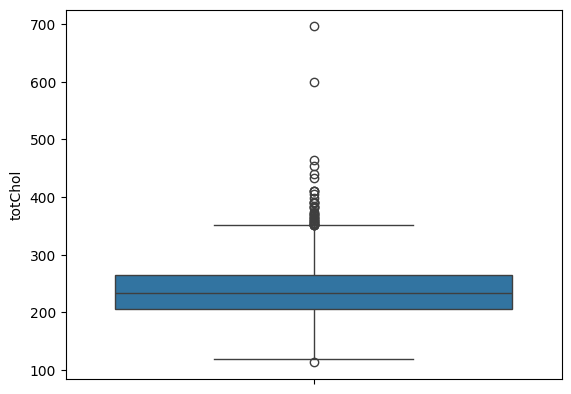

In [13]:
sns.boxplot(data.totChol)
outliers = data[(data['totChol'] > 500)] 
outliers

<Axes: ylabel='totChol'>

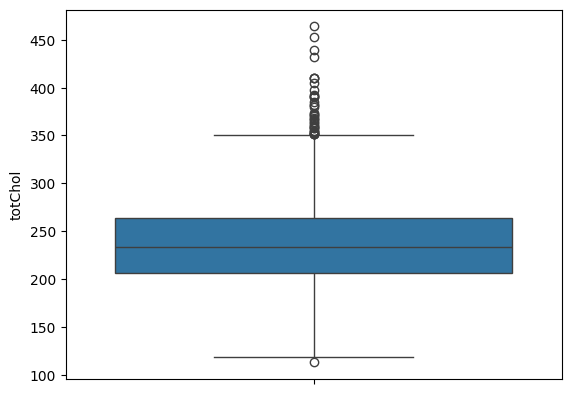

In [14]:
filtered_data = data.drop(data[data.totChol > 599].index)
sns.boxplot(filtered_data.totChol)

In [15]:
scaler = MinMaxScaler(feature_range=(0,1)) 

#assign scaler to column:
filtered_data = pd.DataFrame(scaler.fit_transform(filtered_data), columns=filtered_data.columns)
filtered_data.describe()

,sysBP,glucose,age,totChol,cigsPerDay,diaBP,prevalentHyp,diabetes,BPMeds,male,TenYearCHD
count,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000,3749.000000
mean,0.230991,0.118260,0.462432,0.352447,0.128728,0.369677,0.311550,0.026941,0.030408,0.445185,0.152307
std,0.104228,0.067429,0.225589,0.124179,0.170391,0.126290,0.463189,0.161931,0.171730,0.497053,0.359366
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.158392,0.087571,0.263158,0.264957,0.000000,0.285714,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.210402,0.107345,0.447368,0.344729,0.000000,0.359788,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.283688,0.132768,0.631579,0.430199,0.285714,0.444444,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
filtered_data.TenYearCHD.value_counts()

TenYearCHD
0.0    3178
1.0     571
Name: count, dtype: int64

In [17]:
# Shuffle df
shuffled_df = filtered_data.sample(frac=1,random_state=4)

# Put all the fraud class in a separate dataset.
CHD_df = shuffled_df.loc[shuffled_df['TenYearCHD'] == 1]

#Randomly select 492 observations from the non-fraud (majority class)
non_CHD_df = shuffled_df.loc[shuffled_df['TenYearCHD'] == 0].sample(n=600,random_state=42)

# Concatenate both dataframes again
normalized_df = pd.concat([CHD_df, non_CHD_df])

# check new class counts
normalized_df.TenYearCHD.value_counts()


TenYearCHD
0.0    600
1.0    571
Name: count, dtype: int64

In [18]:
P = normalized_df['TenYearCHD']
X = normalized_df.drop(['TenYearCHD'], axis = 1)
x_train, x_test, y_train, y_test = train_test_split(X,P,test_size = 0.25, random_state = 42)

In [19]:
# Define a result table as a DataFrame
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y = y_test.values

Confusion Matrix (Testing Data):


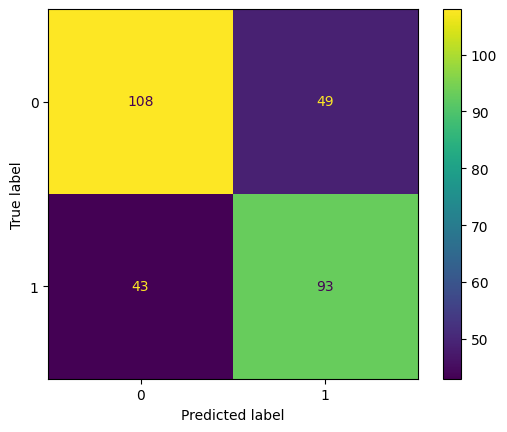

Accuracy Test :  68.60068259385666
Precision Score:  65.49295774647888
Recall Score :  68.38235294117648
F1 score :  66.90647482014388
Mean absolute error : 31.399317406143346
AUC score :  68.58608092918696


C:\Users\Hp\AppData\Local\Temp\ipykernel_18684\3954068409.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"LogisticRegression",


In [20]:
lr = LogisticRegression(max_iter = 100)
lr.fit(x_train,y_train)
test_res = lr.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

######################################

yproba = lr.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"LogisticRegression",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

In [21]:
#Random Forest

Confusion Matrix (Testing Data):


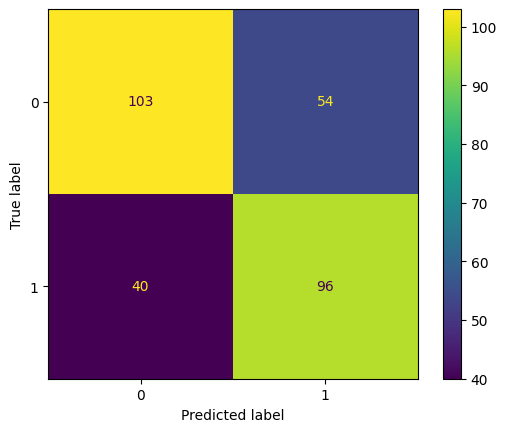

Accuracy Test :  67.91808873720136
Precision Score:  64.0
Recall Score :  70.58823529411765
F1 score :  67.13286713286713
Mean absolute error : 32.081911262798634
AUC score :  68.09666541775947


In [22]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
test_res = rf.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

##################################
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"RandomForestClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)


In [23]:
#DTC

Confusion Matrix (Testing Data):


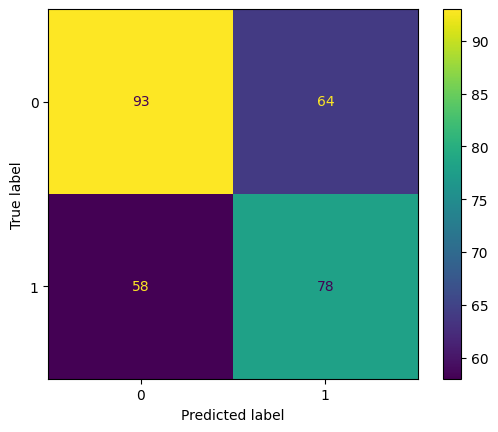

Accuracy Test :  58.36177474402731
Precision Score:  54.929577464788736
Recall Score :  57.35294117647059
F1 score :  56.11510791366907
Mean absolute error : 41.63822525597269
AUC score :  58.294304983139746


In [24]:
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)
test_res = dtc.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)


##############################################

yproba = dtc.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"DecisionTreeClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

In [25]:
#SVC

Confusion Matrix (Testing Data):


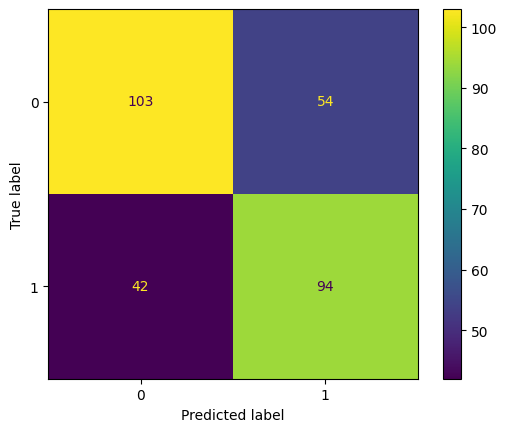

Accuracy Test :  67.23549488054607
Precision Score:  63.51351351351351
Recall Score :  69.11764705882352
F1 score :  66.19718309859154
Mean absolute error : 32.76450511945392
AUC score :  67.36137130011241


In [26]:
svc = SVC(kernel = 'linear', probability = True)
svc.fit(x_train,y_train)
test_res = svc.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

##################################

yproba = svc.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"SVC",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

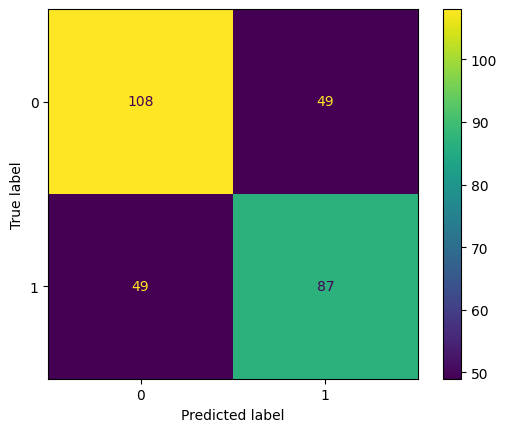

Accuracy Test :  66.55290102389078
Precision Score:  63.970588235294116
Recall Score :  63.970588235294116
F1 score :  63.970588235294116
Mean absolute error : 33.44709897610921
AUC score :  66.3801985762458


In [27]:
#KN Classifier 
kn = KNeighborsClassifier(n_neighbors = 10)
kn.fit(x_train, y_train)

test_res = kn.predict(x_test)

#Confusion Matrix 

confusion_matrix_test = confusion_matrix(y_test, test_res)

obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###
fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

#####################################################


yproba = kn.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"KNeighborsClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

In [28]:
#Naive Bayes

Confusion Matrix (Testing Data):


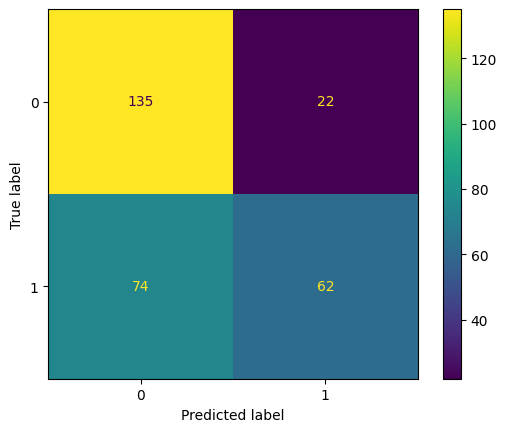

Accuracy Test :  67.23549488054607
Precision Score:  73.80952380952381
Recall Score :  45.588235294117645
F1 score :  56.363636363636374
Mean absolute error : 32.76450511945392
AUC score :  65.78774822030724


In [29]:
#Gaussian
gnb = GaussianNB()
gnb.fit(x_train, y_train)
test_res = gnb.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)


##########################################

yproba = gnb.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"NaiveBayes",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

In [30]:
result_table.set_index('classifiers', inplace=True)

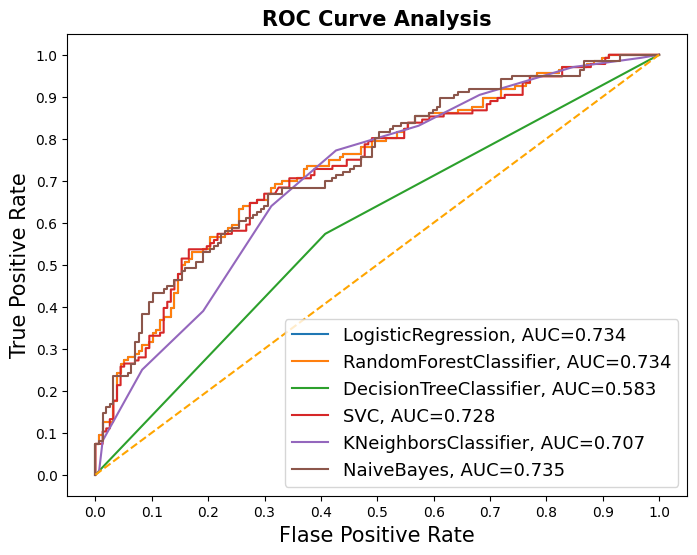

In [31]:
fig = plt.figure(figsize=(8,6))

for i in result_table.index:
    plt.plot(result_table.loc[i]['fpr'], 
             result_table.loc[i]['tpr'], 
             label="{}, AUC={:.3f}".format(i, result_table.loc[i]['auc']))  
                
plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("Flase Positive Rate", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)

plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')

plt.show()